# DAY 1 EDA - ESS 배터리 수명 (MIT-Stanford, Severson 2019)
Batch 1 / 2 / 3 각각에 대해 질문 5개를 수행하고 배치 간 특징을 비교한다.
원본 .mat 로드는 `load_data.py` → `data/cells_raw.pkl` (h5py로 summary + cycle 1~120의 Qdlin만 선택 로드)

- DAY 1에서는 Test 배치(b2, b3)에 대한 모델 평가를 하지 않는다 (배치별 기술 통계만)

In [1]:
import pickle, re, json, numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from scipy.signal import medfilt
from scipy.stats import skew, kurtosis, pearsonr, spearmanr
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': .3,
                     'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
BC = {'b1': '#2a6fdb', 'b2': '#e8871e', 'b3': '#2ca25f'}; B = ['b1', 'b2', 'b3']
EOL = 0.88; DATA = '../data'; FIG = '../figures'   # 노트북은 notebooks/에서 실행
raw = pickle.load(open(f'{DATA}/cells_raw.pkl', 'rb'))
def save(n):
    plt.savefig(f'{FIG}/{n}.png', dpi=170, bbox_inches='tight'); plt.show()
ST = {}   # 장표용 수치 모음

## 0. 데이터 정제
- 인덱스: summary / Qdlin 배열 index j = cycle-1 → cycle 10 = j9, cycle 100 = j99 (b1은 j0이 0으로 채워진 더미)
- 제거 규칙: (1) 다른 실험 프로토콜(VarCharge, SLOWCYCLE) (2) EOL(0.88Ah) 미도달 = 수명 미관측(중도절단)
- 단발성 QD 스파이크는 셀 제거 대신 median filter(k=5)로 보정

In [2]:
rows = []
for t in B:
    for c in raw[t]:
        s = c['summary']; qd = s['QDischarge']
        q_s = qd.copy(); q_s[1:] = medfilt(qd[1:], 5); c['qd_s'] = q_s
        reached = (q_s[1:] <= EOL + 0.0035).any()
        end = int(c['cycle_life_raw']) if np.isfinite(c['cycle_life_raw']) else len(qd)
        noise = np.std(np.diff(qd[1:min(len(qd), end)]))
        reason = ''
        if 'VarCharge' in c['policy'] or 'SLOWCYCLE' in c['policy']:
            reason = '다른 실험 프로토콜'
        elif not np.isfinite(c['cycle_life_raw']) or not reached:
            reason = 'EOL 미도달(수명 미관측)'
        rows.append(dict(batch=t, key=c['key'], policy=c['policy'], life_raw=c['cycle_life_raw'], n=len(qd),
                         QD_last=round(qd[-1], 3), noise_mAh=noise * 1000, reason=reason))
qc = pd.DataFrame(rows)
# 스파이크 점검: 노이즈는 대부분 단발성 스파이크(측정 오류)이므로 셀 제거 대신 median filter(k=5)로 처리
qc['spike_max_mAh'] = [np.abs(c['summary']['QDischarge'][1:101] - medfilt(c['summary']['QDischarge'][1:101], 5)).max() * 1000 for t in B for c in raw[t]]
print(qc[qc.reason != ''].to_string())
print('spike>30mAh 셀:', qc[(qc.spike_max_mAh > 30) & (qc.reason == '')][['key', 'spike_max_mAh']].round(0).values.tolist())
ST['spike_cells'] = qc[(qc.spike_max_mAh > 30) & (qc.reason == '')][['key', 'spike_max_mAh']].round(0).values.tolist()
cnt = pd.DataFrame({'원본': qc.groupby('batch').size(), '제거': qc[qc.reason != ''].groupby('batch').size(),
                    '최종': qc[qc.reason == ''].groupby('batch').size()}).fillna(0).astype(int)
print(cnt); ST['count'] = cnt.to_dict(); qc.to_csv(f'{DATA}/data_cleaning_log.csv', index=False, encoding='utf-8-sig')
ST['removed'] = qc[qc.reason != ''][['batch', 'key', 'policy', 'QD_last', 'reason']].to_dict('records')
keep = set(qc[qc.reason == ''].key)
cells = [c for t in B for c in raw[t] if c['key'] in keep]
for c in cells: c['life'] = c['cycle_life_raw']

    batch    key                       policy  life_raw     n  QD_last   noise_mAh           reason  spike_max_mAh
0      b1   b1c0               3.6C(80%)-3.6C    1190.0  1189    1.026   19.898120  EOL 미도달(수명 미관측)       464.2730
1      b1   b1c1               3.6C(80%)-3.6C    1179.0  1178    1.038    0.402398  EOL 미도달(수명 미관측)         2.6499
2      b1   b1c2               3.6C(80%)-3.6C    1177.0  1176    1.043    0.364315  EOL 미도달(수명 미관측)         2.2887
3      b1   b1c3                   4C(80%)-4C    1226.0  1225    0.971    0.451482  EOL 미도달(수명 미관측)         3.2501
4      b1   b1c4                   4C(80%)-4C    1227.0  1226    1.022    0.750037  EOL 미도달(수명 미관측)         3.4157
8      b1   b1c8               5.4C(40%)-3.6C     879.0   878    0.969    0.306997  EOL 미도달(수명 미관측)         0.0894
10     b1  b1c10                 5.4C(50%)-3C     906.0   905    0.961    0.503183  EOL 미도달(수명 미관측)         5.2893
12     b1  b1c12               5.4C(50%)-3.6C     902.0   901    0.913    0.3526

## 피처 테이블 (초기 cycle 2~100 정보만 사용)

In [3]:
PR = re.compile(r'([\d.]+)C\(([\d.]+)%\)-([\d.]+)C')
def pol(p):
    c1, q1, c2 = map(float, PR.search(p).groups())
    t = min(q1, 80) / 100 / c1 + max(0, 80 - q1) / 100 / c2      # 0→80% 충전 시간(h)
    return dict(C1=c1, Q1=q1, C2=c2, avgC_80=0.8 / t, newstruct=int('newstructure' in p))
def feats(c):
    s = c['summary']; q = c['qdlin']; dq = q[99] - q[9]
    j = np.arange(1, 100); qd = c['qd_s'][1:100]
    ir = s['IR'][1:100]; ir = np.where(ir > 0, ir, np.nan)
    p1 = np.polyfit(j, qd, 1); p2 = np.polyfit(j[-10:], qd[-10:], 1)
    f = dict(batch=c['batch'], key=c['key'], policy=c['policy'], life=c['life'], log_life=np.log10(c['life']),
             dQ_logvar=np.log10(np.var(dq)), dQ_logmin=np.log10(abs(dq.min())), dQ_mean=dq.mean() * 1000,
             dQ_skew=skew(dq), dQ_kurt=np.log10(abs(kurtosis(dq))),
             QD_2=qd[0], QD_max_m2=(qd.max() - qd[0]) * 1000, QD_100_m10=(c['qd_s'][99] - c['qd_s'][9]) * 1000,
             QD_slope_2_100=p1[0] * 1e6, QD_icpt_2_100=p1[1], QD_slope_91_100=p2[0] * 1e6,
             IR_2=ir[0], IR_min=np.nanmin(ir) if np.isfinite(ir).any() else np.nan,
             IR_100_m2=(ir[-1] - ir[0]) * 1e4,
             Tavg_mean=np.nanmean(s['Tavg'][1:100]), Tmax_max=np.nanmax(s['Tmax'][1:100]),
             Tint=np.nansum(s['Tavg'][1:100] - s['Tmin'][1:100]), chargetime_2_6=np.nanmean(s['chargetime'][1:6]))
    f.update(pol(c['policy'])); return f
F = pd.DataFrame([feats(c) for c in cells])
FEATS = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'dQ_skew', 'dQ_kurt', 'QD_2', 'QD_max_m2', 'QD_100_m10',
         'QD_slope_2_100', 'QD_icpt_2_100', 'QD_slope_91_100', 'IR_2', 'IR_min', 'IR_100_m2',
         'Tavg_mean', 'Tmax_max', 'Tint', 'chargetime_2_6', 'C1', 'Q1', 'C2', 'avgC_80', 'newstruct']
print('결측:', F[FEATS].isna().sum()[lambda x: x > 0].to_dict())
ST['missing'] = F[FEATS].isna().groupby(F.batch).sum().loc[:, lambda d: d.sum() > 0].to_dict()

결측: {'IR_2': 6, 'IR_min': 6, 'IR_100_m2': 6}


## Q1. Cycle Life 분포

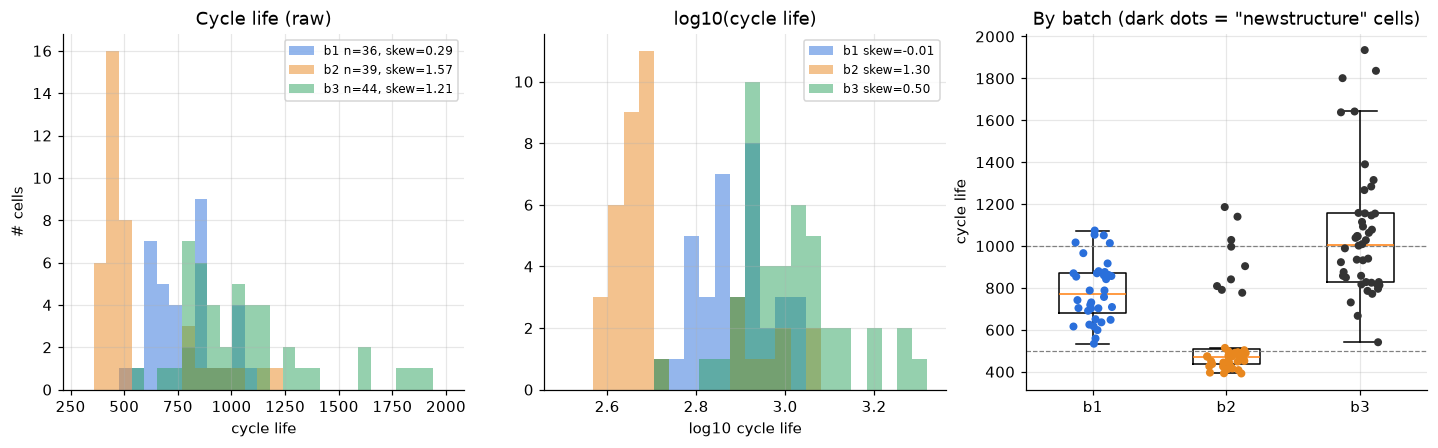

       count    min  median    mean     max    std  skew  long>1000 %  short<500 %  >550 %  newstruct %
batch                                                                                                  
b1        36  534.0   772.0   788.0  1074.0  149.0  0.29         13.9          0.0    97.2          0.0
b2        39  392.0   472.0   566.0  1186.0  222.0  1.57          7.7         71.8    23.1         23.1
b3        44  541.0  1006.0  1060.0  1935.0  314.0  1.21         52.3          0.0    97.7        100.0
   batch    key                       policy    life  avgC_80  dQ_logvar
0     b2   b2c7  4.8C(80%)-4.8C-newstructure   777.0     4.80      -4.23
1     b2   b2c8    5.2C(58%)-4C-newstructure   904.0     4.80      -4.10
2     b2   b2c9  5.6C(26%)-4.5C-newstructure   791.0     4.81      -4.34
3     b2  b2c32  4.8C(80%)-4.8C-newstructure   809.0     4.80      -4.13
4     b2  b2c33    5.2C(58%)-4C-newstructure  1140.0     4.80      -4.23
5     b2  b2c34  5.6C(26%)-4.5C-newstructu

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
bins = np.linspace(300, 2000, 30); lb = np.linspace(2.5, 3.32, 25)
for t in B:
    d = F[F.batch == t]
    ax[0].hist(d.life, bins=bins, alpha=.5, color=BC[t], label=f'{t} n={len(d)}, skew={skew(d.life):.2f}')
    ax[1].hist(d.log_life, bins=lb, alpha=.5, color=BC[t], label=f'{t} skew={skew(d.log_life):.2f}')
ax[0].set(title='Cycle life (raw)', xlabel='cycle life', ylabel='# cells'); ax[0].legend(fontsize=8)
ax[1].set(title='log10(cycle life)', xlabel='log10 cycle life'); ax[1].legend(fontsize=8)
for i, t in enumerate(B):
    d = F[F.batch == t]; x = i + np.random.RandomState(0).uniform(-.15, .15, len(d))
    ax[2].scatter(x, d.life, c=['#333' if n else BC[t] for n in d.newstruct], s=18, zorder=3)
    ax[2].boxplot(d.life, positions=[i], widths=.5, showfliers=False)
ax[2].axhline(1000, ls='--', c='gray', lw=.8); ax[2].axhline(500, ls='--', c='gray', lw=.8)
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(B)
ax[2].set(title='By batch (dark dots = "newstructure" cells)', ylabel='cycle life')
save('Q1_cycle_life_dist')
q1 = F.groupby('batch').life.agg(['count', 'min', 'median', 'mean', 'max', 'std']).round(0)
q1['skew'] = F.groupby('batch').life.apply(skew).round(2)
q1['long>1000 %'] = F.groupby('batch').life.apply(lambda x: (x > 1000).mean() * 100).round(1)
q1['short<500 %'] = F.groupby('batch').life.apply(lambda x: (x < 500).mean() * 100).round(1)
q1['>550 %'] = F.groupby('batch').life.apply(lambda x: (x > 550).mean() * 100).round(1)
q1['newstruct %'] = F.groupby('batch').newstruct.mean().mul(100).round(1)
print(q1); ST['q1'] = q1.reset_index().to_dict('records')
ST['q1_all'] = dict(skew_raw=skew(F.life), skew_log=skew(F.log_life), long=(F.life > 1000).mean(), short=(F.life < 500).mean())
out = []
for t in B:
    d = F[F.batch == t]; q25, q75 = d.life.quantile([.25, .75]); iqr = q75 - q25
    o = d[(d.life < q25 - 1.5 * iqr) | (d.life > q75 + 1.5 * iqr)]
    for _, r in o.iterrows():
        out.append(dict(batch=t, key=r.key, policy=r.policy, life=r.life, avgC_80=round(r.avgC_80, 2), dQ_logvar=round(r.dQ_logvar, 2)))
print(pd.DataFrame(out)); ST['q1_outliers'] = out
sh = F.nsmallest(6, 'life')[['batch', 'key', 'policy', 'life', 'avgC_80', 'Tavg_mean', 'dQ_logvar']]
print(sh); ST['q1_short'] = sh.round(2).to_dict('records')

                           count   mean    min     max
pol_base        newstruct                             
3.6C(30%)-6C    0              2  421.0  416.0   426.0
3.6C(9%)-5C     0              2  394.0  393.0   396.0
4.65C(44%)-5C   0              2  482.0  466.0   499.0
4.65C(69%)-6C   0              2  452.0  444.0   460.0
4.8C(80%)-4.8C  0              5  484.0  437.0   514.0
                1              3  872.0  777.0  1029.0
5.2C(50%)-4.25C 0              5  454.0  424.0   474.0
5.2C(58%)-4C    0              4  478.0  452.0   493.0
                1              3  962.0  841.0  1140.0
5.6C(26%)-4.5C  0              6  448.0  412.0   491.0
                1              3  991.0  791.0  1186.0
6C(60%)-3C      0              2  400.0  392.0   408.0


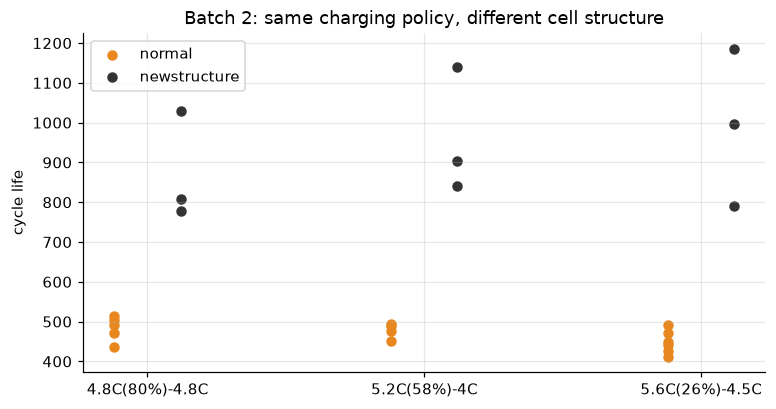

In [5]:
# 같은 정책인데 셀 구조(newstructure)만 다른 경우 (Batch 2)
F['pol_base'] = F.policy.str.replace('-newstructure', '')
cmp = F[F.batch == 'b2'].groupby(['pol_base', 'newstruct']).life.agg(['count', 'mean', 'min', 'max']).round(0)
print(cmp); ST['q1_newstruct'] = cmp.reset_index().to_dict('records')
fig, ax = plt.subplots(figsize=(8, 4))
pb = sorted(F[(F.batch == 'b2') & (F.newstruct == 1)].pol_base.unique())
for i, p in enumerate(pb):
    for ns, col, off in ((0, BC['b2'], -.12), (1, '#333', .12)):
        d = F[(F.batch == 'b2') & (F.pol_base == p) & (F.newstruct == ns)]
        ax.scatter([i + off] * len(d), d.life, c=col, s=34, label=('normal' if ns == 0 else 'newstructure') if i == 0 else None)
ax.set_xticks(range(len(pb))); ax.set_xticklabels(pb); ax.legend()
ax.set(title='Batch 2: same charging policy, different cell structure', ylabel='cycle life')
save('Q1_newstructure_b2')

## Q2. 열화 곡선 · Knee point

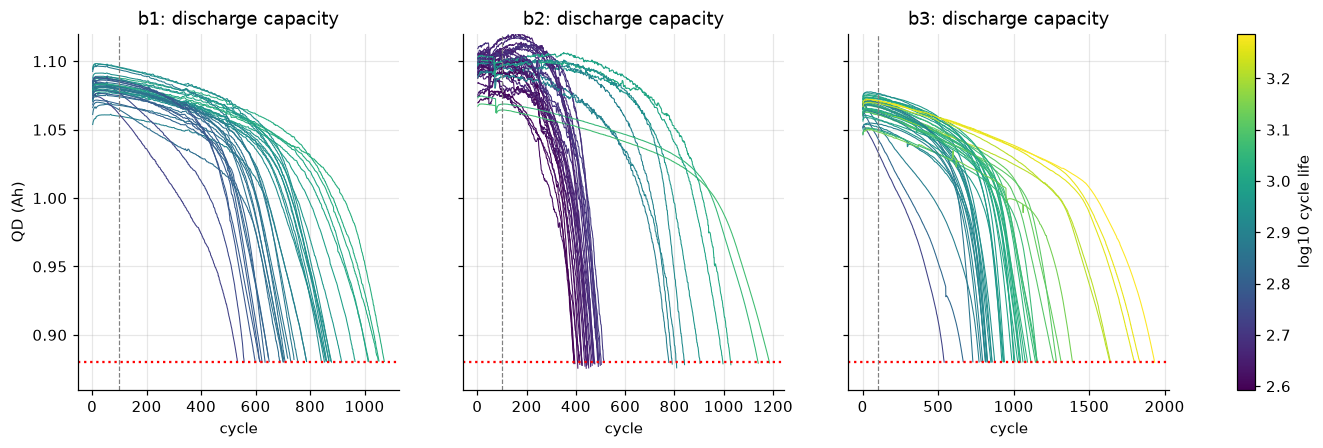

       knee_med  ratio_med  accel_med  pre_slope_med  post_slope_med  r(knee,life)
batch                                                                             
b1        579.0       0.75      10.51         -72.46         -795.23         0.981
b2        343.0       0.75      11.38        -103.70        -1335.55         0.994
b3        820.0       0.79       9.98         -61.08         -684.51         0.991
QD100-QD10 (mAh)
        mean   std    min    max
batch                          
b1    -1.61  2.91 -14.43   1.85
b2     0.68  5.93 -20.36  11.17
b3    -2.20  4.24 -18.67   0.35
{'b1': {'QD_100_m10': np.float64(0.5541388198145784), 'QD_2': np.float64(0.15658710913885576)}, 'b2': {'QD_100_m10': np.float64(-0.24430316879125452), 'QD_2': np.float64(-0.21660614816832754)}, 'b3': {'QD_100_m10': np.float64(0.4406667978109926), 'QD_2': np.float64(0.17051544025664586)}}


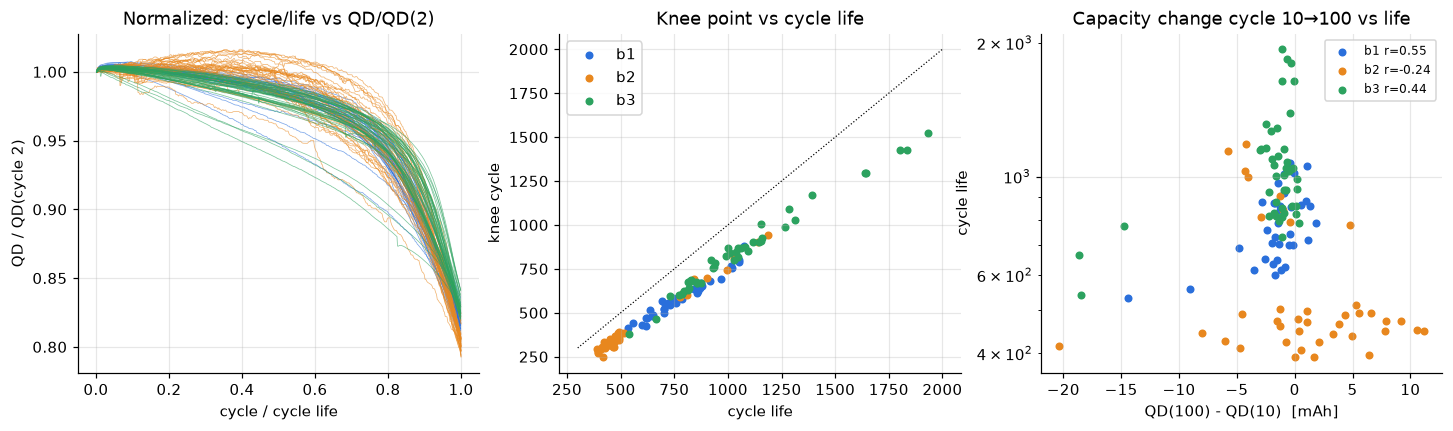

In [6]:
norm = plt.Normalize(F.log_life.min(), F.log_life.max()); cm = plt.cm.viridis
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for a, t in zip(ax, B):
    for c in [c for c in cells if c['batch'] == t]:
        n = min(int(c['life']), len(c['qd_s']))
        a.plot(np.arange(2, n + 1), c['qd_s'][1:n], color=cm(norm(np.log10(c['life']))), lw=.7)
    a.axhline(EOL, c='r', ls=':'); a.axvline(100, c='gray', ls='--', lw=.8)
    a.set(title=f'{t}: discharge capacity', xlabel='cycle', ylim=(.86, 1.12))
ax[0].set_ylabel('QD (Ah)')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cm), ax=ax, label='log10 cycle life'); save('Q2_QD_curves')

def knee(x, y):
    best, bs = None, np.inf
    for k in range(int(len(x) * .2), int(len(x) * .97), 3):
        sse = 0
        for xx, yy in ((x[:k], y[:k]), (x[k:], y[k:])):
            p = np.polyfit(xx, yy, 1); sse += ((np.polyval(p, xx) - yy) ** 2).sum()
        if sse < bs: best, bs = k, sse
    return x[best], np.polyfit(x[:best], y[:best], 1)[0], np.polyfit(x[best:], y[best:], 1)[0]
K = []
for c in cells:
    n = min(int(c['life']), len(c['qd_s'])); x = np.arange(2, n + 1).astype(float); y = c['qd_s'][1:n]
    kc, s1, s2 = knee(x, y)
    K.append(dict(key=c['key'], batch=c['batch'], life=c['life'], knee=kc, ratio=kc / c['life'], slope_pre=s1 * 1e6, slope_post=s2 * 1e6))
K = pd.DataFrame(K); K['accel'] = K.slope_post / K.slope_pre
F = F.merge(K[['key', 'knee']], on='key')
kq = K.groupby('batch').agg(knee_med=('knee', 'median'), ratio_med=('ratio', 'median'), accel_med=('accel', 'median'),
                            pre_slope_med=('slope_pre', 'median'), post_slope_med=('slope_post', 'median')).round(2)
kq['r(knee,life)'] = K.groupby('batch').apply(lambda d: pearsonr(d.knee, d.life)[0]).round(3)
print(kq); ST['q2_knee'] = kq.reset_index().to_dict('records')
ST['q2_ratio_all'] = K.ratio.median(); ST['q2_accel_all'] = K.accel.median()
fade = F.groupby('batch').QD_100_m10.describe()[['mean', 'std', 'min', 'max']].round(2); print('QD100-QD10 (mAh)\n', fade)
ST['q2_fade'] = fade.reset_index().to_dict('records')
ST['q2_r_qd'] = {t: dict(QD_100_m10=pearsonr(F[F.batch == t].QD_100_m10, F[F.batch == t].log_life)[0],
                         QD_2=pearsonr(F[F.batch == t].QD_2, F[F.batch == t].log_life)[0]) for t in B}
print(ST['q2_r_qd'])
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
for c in cells:
    n = min(int(c['life']), len(c['qd_s'])); y = c['qd_s'][1:n]
    ax[0].plot(np.arange(2, n + 1) / c['life'], y / y[0], color=BC[c['batch']], lw=.5, alpha=.6)
ax[0].set(title='Normalized: cycle/life vs QD/QD(2)', xlabel='cycle / cycle life', ylabel='QD / QD(cycle 2)')
for t in B:
    d = K[K.batch == t]; ax[1].scatter(d.life, d.knee, c=BC[t], s=18, label=t)
    e = F[F.batch == t]
    ax[2].scatter(e.QD_100_m10, e.life, c=BC[t], s=18, label=f"{t} r={ST['q2_r_qd'][t]['QD_100_m10']:.2f}")
ax[1].plot([300, 2000], [300, 2000], 'k:', lw=.8); ax[1].set(title='Knee point vs cycle life', xlabel='cycle life', ylabel='knee cycle'); ax[1].legend()
ax[2].set(yscale='log', title='Capacity change cycle 10→100 vs life', xlabel='QD(100) - QD(10)  [mAh]', ylabel='cycle life'); ax[2].legend(fontsize=8)
save('Q2_knee_fade')

## Q3. ΔQ(V) = Q100(V) − Q10(V)

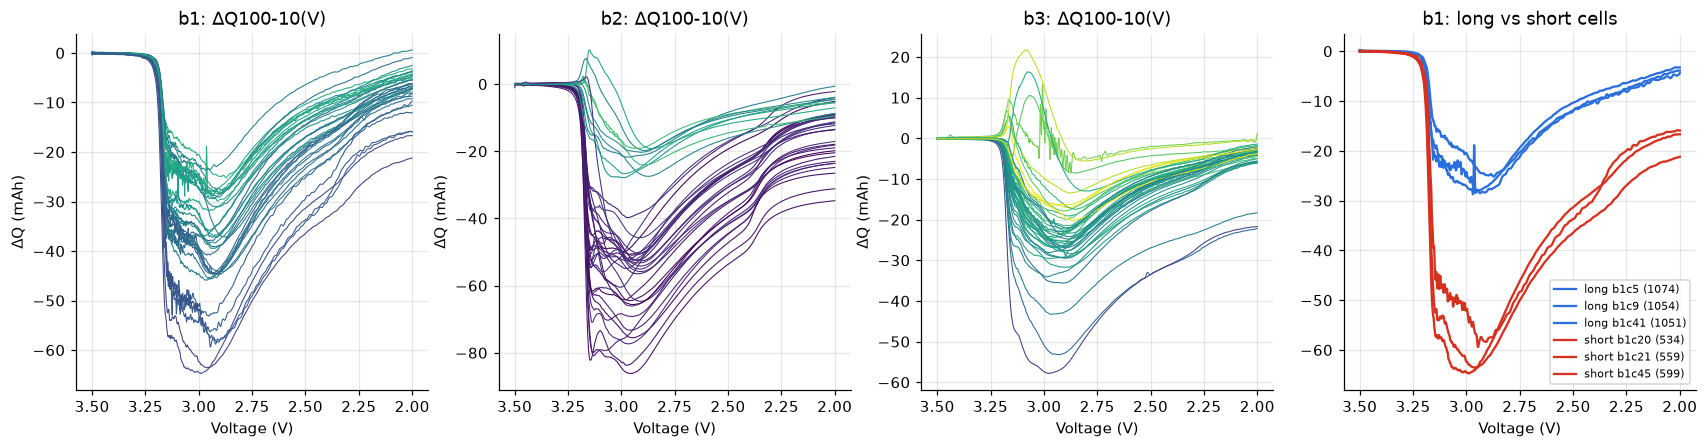

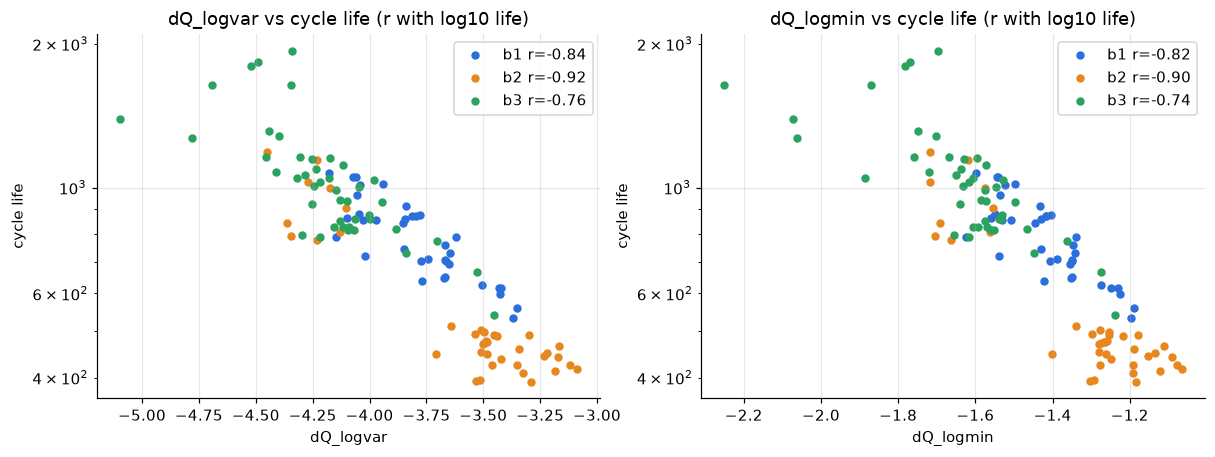

              b1     b2     b3    all
dQ_logvar -0.844 -0.918 -0.762 -0.897
dQ_logmin -0.821 -0.901 -0.744 -0.876
dQ_mean    0.798  0.791  0.720  0.852
dQ_skew   -0.434 -0.126  0.188 -0.028
dQ_kurt   -0.004 -0.662  0.260 -0.008
{'b1': 2.935, 'b2': 2.959, 'b3': 2.905} {'b1': {'min': -4.18, 'median': -3.79, 'max': -3.35}, 'b2': {'min': -4.45, 'median': -3.49, 'max': -3.09}, 'b3': {'min': -5.1, 'median': -4.18, 'max': -3.45}}


In [7]:
V = cells[0]['vdlin'] if cells[0]['vdlin'] is not None else np.linspace(3.5, 2.0, 1000)
fig, ax = plt.subplots(1, 4, figsize=(19, 4.2))
for a, t in zip(ax[:3], B):
    for c in [c for c in cells if c['batch'] == t]:
        a.plot(V, (c['qdlin'][99] - c['qdlin'][9]) * 1000, color=cm(norm(np.log10(c['life']))), lw=.7)
    a.set(title=f'{t}: ΔQ100-10(V)', xlabel='Voltage (V)', ylabel='ΔQ (mAh)'); a.invert_xaxis()
d1 = F[F.batch == 'b1']
for keys, col, lab in ((d1.nlargest(3, 'life').key, '#2a6fdb', 'long'), (d1.nsmallest(3, 'life').key, '#d7301f', 'short')):
    for k in keys:
        c = next(c for c in cells if c['key'] == k)
        ax[3].plot(V, (c['qdlin'][99] - c['qdlin'][9]) * 1000, color=col, label=f"{lab} {k} ({int(c['life'])})")
ax[3].invert_xaxis(); ax[3].legend(fontsize=7); ax[3].set(title='b1: long vs short cells', xlabel='Voltage (V)')
save('Q3_dQ_curves')
DQ = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'dQ_skew', 'dQ_kurt']
fig, ax = plt.subplots(1, 2, figsize=(13, 4.3))
for a, f in zip(ax, ['dQ_logvar', 'dQ_logmin']):
    for t in B:
        d = F[F.batch == t]; a.scatter(d[f], d.life, c=BC[t], s=20, label=f'{t} r={pearsonr(d[f], d.log_life)[0]:.2f}')
    a.set(yscale='log', title=f'{f} vs cycle life (r with log10 life)', xlabel=f, ylabel='cycle life'); a.legend()
save('Q3_dQ_scatter')
q3 = pd.DataFrame({**{t: [pearsonr(F[F.batch == t][f], F[F.batch == t].log_life)[0] for f in DQ] for t in B},
                   'all': [pearsonr(F[f], F.log_life)[0] for f in DQ]}, index=DQ).round(3)
print(q3); ST['q3_r'] = q3.to_dict()
F['dQ_vmin'] = [V[np.argmin(c['qdlin'][99] - c['qdlin'][9])] for c in cells]
ST['q3_vmin'] = F.groupby('batch').dQ_vmin.median().round(3).to_dict()
ST['q3_logvar_range'] = F.groupby('batch').dQ_logvar.agg(['min', 'median', 'max']).round(2).to_dict('index')
print(ST['q3_vmin'], ST['q3_logvar_range'])

## Q4. 충전 조건(C-rate)과 수명

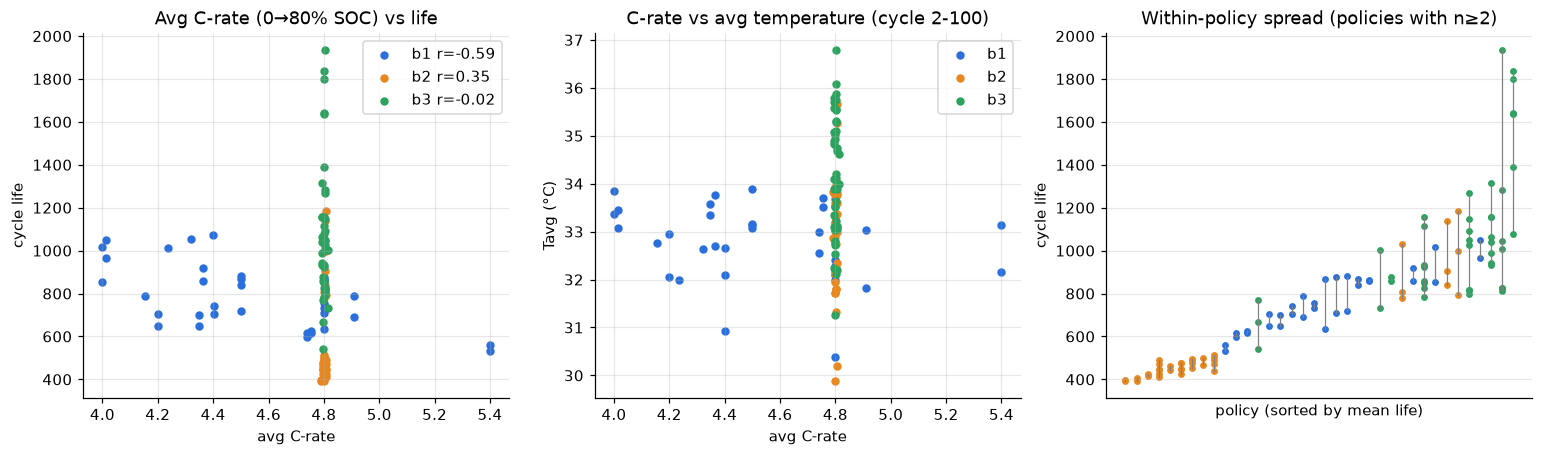

   batch                       policy  n         mean     min     max  max/min
0     b2                  3.6C(9%)-5C  2   394.500000   393.0   396.0     1.01
1     b2                   6C(60%)-3C  2   400.000000   392.0   408.0     1.04
2     b2                 3.6C(30%)-6C  2   421.000000   416.0   426.0     1.02
3     b2               5.6C(26%)-4.5C  6   448.500000   412.0   491.0     1.19
4     b2                4.65C(69%)-6C  2   452.000000   444.0   460.0     1.04
5     b2              5.2C(50%)-4.25C  5   454.000000   424.0   474.0     1.12
6     b2                 5.2C(58%)-4C  4   477.750000   452.0   493.0     1.09
7     b2                4.65C(44%)-5C  2   482.500000   466.0   499.0     1.07
8     b2               4.8C(80%)-4.8C  5   483.600000   437.0   514.0     1.18
9     b1               5.4C(80%)-5.4C  2   546.500000   534.0   559.0     1.05
10    b1                 8C(35%)-3.6C  2   607.500000   599.0   616.0     1.03
11    b1                 7C(40%)-3.6C  2   621.00000

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.3))
for t in B:
    d = F[F.batch == t]
    ax[0].scatter(d.avgC_80, d.life, c=BC[t], s=20, label=f'{t} r={pearsonr(d.avgC_80, d.log_life)[0]:.2f}')
    ax[1].scatter(d.avgC_80, d.Tavg_mean, c=BC[t], s=20, label=t)
ax[0].set(title='Avg C-rate (0→80% SOC) vs life', xlabel='avg C-rate', ylabel='cycle life'); ax[0].legend()
ax[1].set(title='C-rate vs avg temperature (cycle 2-100)', xlabel='avg C-rate', ylabel='Tavg (°C)'); ax[1].legend()
g = F.groupby(['batch', 'policy']).life
P_ = pd.DataFrame({'n': g.size(), 'mean': g.mean(), 'min': g.min(), 'max': g.max()}).reset_index()
P_ = P_[P_.n >= 2].sort_values('mean').reset_index(drop=True)
for i, r in P_.iterrows():
    d = F[(F.batch == r.batch) & (F.policy == r.policy)]
    ax[2].plot([i, i], [r['min'], r['max']], c='gray', lw=.8); ax[2].scatter([i] * len(d), d.life, c=BC[r.batch], s=12)
ax[2].set(title='Within-policy spread (policies with n≥2)', xlabel='policy (sorted by mean life)', ylabel='cycle life'); ax[2].set_xticks([])
save('Q4_crate')
P_['max/min'] = (P_['max'] / P_['min']).round(2); print(P_.to_string())
r_c = {t: pearsonr(F[F.batch == t].avgC_80, F[F.batch == t].log_life)[0] for t in B}; r_c['all'] = pearsonr(F.avgC_80, F.log_life)[0]
r_ct = {t: pearsonr(F[F.batch == t].avgC_80, F[F.batch == t].Tavg_mean)[0] for t in B}
r2 = {}
for t in B:
    d = F[F.batch == t]; m = d.groupby('policy').log_life.transform('mean')
    r2[t] = 1 - ((d.log_life - m) ** 2).sum() / ((d.log_life - d.log_life.mean()) ** 2).sum()
ST['q4'] = dict(r_crate_life=r_c, r_crate_temp=r_ct, policy_R2=r2, maxmin=float(P_['max/min'].max()),
                n_policy={t: F[F.batch == t].policy.nunique() for t in B}, policies=P_.round(2).to_dict('records'),
                r_c1={t: pearsonr(F[F.batch == t].C1, F[F.batch == t].log_life)[0] for t in B},
                r_charget={t: pearsonr(F[F.batch == t].chargetime_2_6, F[F.batch == t].log_life)[0] for t in B},
                r_temp_life={t: pearsonr(F[F.batch == t].Tavg_mean, F[F.batch == t].log_life)[0] for t in B})
d = F[F.batch == 'b1']; hi = d[d.avgC_80 >= d.avgC_80.quantile(.75)].life; lo = d[d.avgC_80 <= d.avgC_80.quantile(.25)].life
ST['q4_b1_fast_vs_slow'] = dict(fast_mean=hi.mean(), slow_mean=lo.mean(), fast_n=len(hi), slow_n=len(lo))
print({k: v for k, v in ST['q4'].items() if k != 'policies'}, ST['q4_b1_fast_vs_slow'])

## Q5. 상관관계 · 다중공선성

                    b1     b2     b3    all  sign_same  min|r|
dQ_logvar       -0.844 -0.918 -0.762 -0.897       True   0.762
dQ_logmin       -0.821 -0.901 -0.744 -0.876       True   0.744
dQ_mean          0.798  0.791  0.720  0.852       True   0.720
avgC_80         -0.594  0.350 -0.017 -0.155      False   0.017
chargetime_2_6   0.575 -0.942  0.601  0.226      False   0.575
QD_slope_2_100   0.556 -0.372  0.432 -0.142      False   0.372
QD_100_m10       0.554 -0.244  0.441 -0.116      False   0.244
QD_slope_91_100  0.535  0.303  0.459  0.084       True   0.303
dQ_skew         -0.434 -0.126  0.188 -0.028      False   0.126
IR_min           0.345 -0.574  0.172 -0.422      False   0.172
C2              -0.292 -0.110 -0.125 -0.179       True   0.110
QD_max_m2        0.281 -0.389  0.006 -0.452      False   0.006
C1              -0.238  0.196  0.018  0.088      False   0.018
Tint            -0.186  0.128 -0.048  0.136      False   0.048
Q1              -0.181  0.164  0.520  0.120      False 

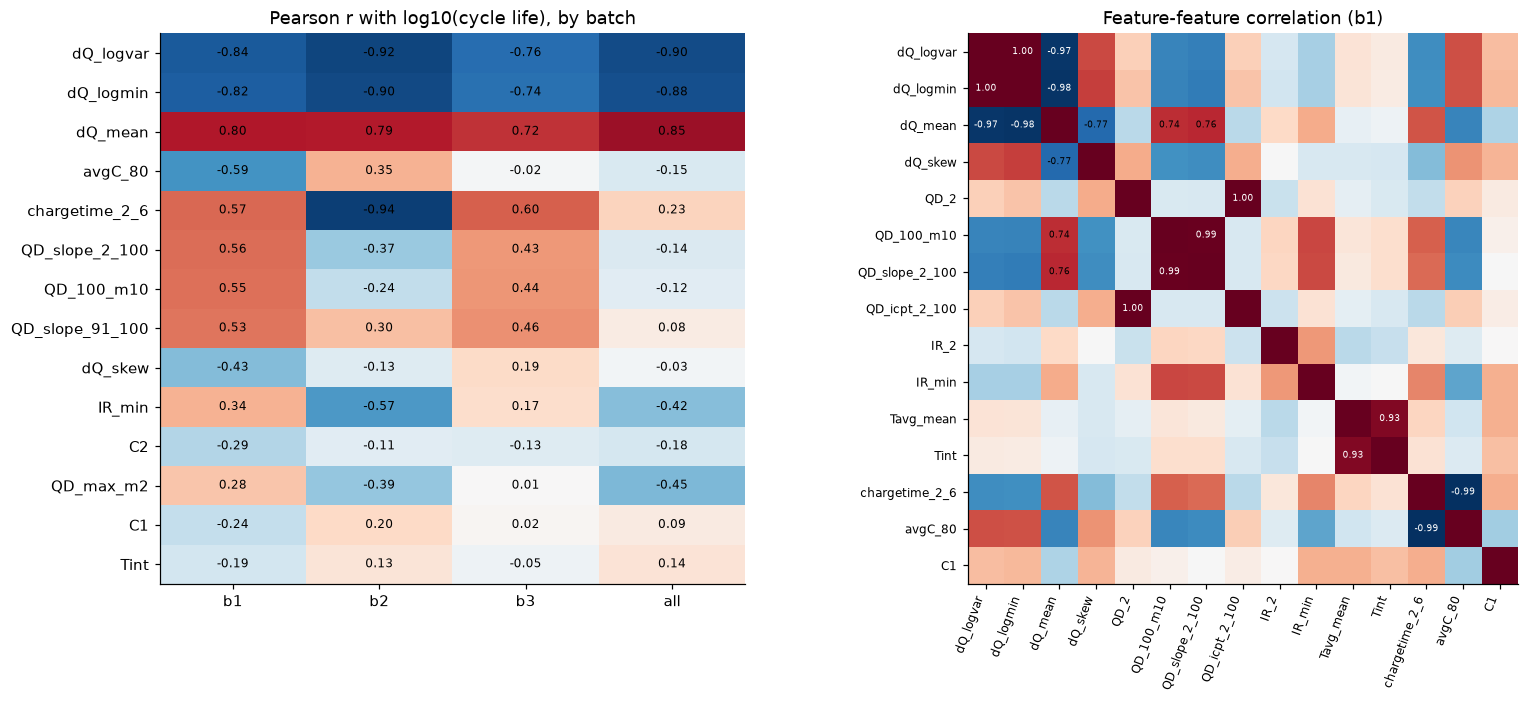

dQ_logvar         292.4
dQ_logmin         347.4
dQ_mean            36.2
QD_2                2.4
QD_slope_2_100      8.0
IR_min              2.7
Tavg_mean          12.4
Tint               11.2
chargetime_2_6    269.0
avgC_80           292.5
dtype: float64
[('dQ_logvar', 'dQ_logmin', np.float64(0.996)), ('dQ_logvar', 'dQ_mean', np.float64(-0.971)), ('dQ_logmin', 'dQ_mean', np.float64(-0.977)), ('QD_2', 'QD_icpt_2_100', np.float64(0.998)), ('QD_100_m10', 'QD_slope_2_100', np.float64(0.992)), ('Tavg_mean', 'Tint', np.float64(0.93)), ('chargetime_2_6', 'avgC_80', np.float64(-0.995))]
DONE


In [9]:
FE = [f for f in FEATS if f != 'newstruct']
def ctab(m):
    o = {t: F[F.batch == t][FE].corrwith(F[F.batch == t].log_life, method=m) for t in B}
    o['all'] = F[FE].corrwith(F.log_life, method=m); return pd.DataFrame(o)
pr = ctab('pearson'); sp = ctab('spearman')
pr['sign_same'] = (np.sign(pr[B]).nunique(axis=1) == 1); pr['min|r|'] = pr[B].abs().min(axis=1)
pr = pr.reindex(pr['b1'].abs().sort_values(ascending=False).index); print(pr.round(3))
ST['q5_pearson'] = pr.round(3).to_dict('index'); ST['q5_spear'] = sp.round(3).to_dict('index')
fig, ax = plt.subplots(1, 2, figsize=(17, 6.5), gridspec_kw={'width_ratios': [1, 1.25]})
top = pr.index[:14]
ax[0].imshow(pr.loc[top, B + ['all']].values.astype(float), cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax[0].set_yticks(range(len(top))); ax[0].set_yticklabels(top); ax[0].set_xticks(range(4)); ax[0].set_xticklabels(B + ['all']); ax[0].grid(False)
for i in range(len(top)):
    for j, t in enumerate(B + ['all']):
        ax[0].text(j, i, f'{pr.loc[top[i], t]:.2f}', ha='center', va='center', fontsize=8)
ax[0].set_title('Pearson r with log10(cycle life), by batch')
SEL = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'dQ_skew', 'QD_2', 'QD_100_m10', 'QD_slope_2_100', 'QD_icpt_2_100',
       'IR_2', 'IR_min', 'Tavg_mean', 'Tint', 'chargetime_2_6', 'avgC_80', 'C1']
cmx = F[F.batch == 'b1'][SEL].corr()
ax[1].imshow(cmx, cmap='RdBu_r', vmin=-1, vmax=1); ax[1].grid(False)
ax[1].set_xticks(range(len(SEL))); ax[1].set_xticklabels(SEL, rotation=70, ha='right', fontsize=8)
ax[1].set_yticks(range(len(SEL))); ax[1].set_yticklabels(SEL, fontsize=8)
for i in range(len(SEL)):
    for j in range(len(SEL)):
        v = cmx.iloc[i, j]
        if abs(v) >= .7 and i != j:
            ax[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6, color='w' if abs(v) > .85 else 'k')
ax[1].set_title('Feature-feature correlation (b1)'); save('Q5_corr')
def vif(X):
    X = (X - X.mean()) / X.std(); o = {}
    for c in X:
        A = np.column_stack([np.ones(len(X)), X.drop(columns=c).values]); y = X[c].values
        b = np.linalg.lstsq(A, y, rcond=None)[0]; r2_ = 1 - ((y - A @ b) ** 2).sum() / ((y - y.mean()) ** 2).sum(); o[c] = 1 / max(1 - r2_, 1e-6)
    return pd.Series(o)
VC = ['dQ_logvar', 'dQ_logmin', 'dQ_mean', 'QD_2', 'QD_slope_2_100', 'IR_min', 'Tavg_mean', 'Tint', 'chargetime_2_6', 'avgC_80']
v = vif(F[F.batch == 'b1'][VC].dropna()).round(1); print(v); ST['q5_vif'] = v.to_dict()
pairs = [(a, b, cmx.loc[a, b]) for i, a in enumerate(SEL) for b in SEL[i + 1:] if abs(cmx.loc[a, b]) >= .8]
ST['q5_pairs'] = [(a, b, round(r, 3)) for a, b, r in pairs]; print(ST['q5_pairs'])
F.to_csv(f'{DATA}/features_cycle100.csv', index=False)
json.dump(ST, open(f'{DATA}/eda_stats.json', 'w'), default=lambda o: float(o) if np.isscalar(o) else str(o), ensure_ascii=False, indent=1)
print('DONE')

## 장표 보조 수치
PDF에 쓰인 수치 중 위 셀에서 계산하지 않은 값. 모두 배치별 기술 통계이며, 배치 간 모델 평가는 하지 않는다.

In [10]:
X = {}
X['skew_log'] = F.groupby('batch').log_life.apply(skew).round(2).to_dict()                      # 4장
ex = pd.Series([len(c['summary']['QDischarge']) - c['life'] for c in cells if c['batch'] == 'b2'])
X['b2_after_eol'] = dict(min=ex.min(), median=ex.median(), max=ex.max())                         # 3장
b2 = F[F.batch == 'b2']
X['b2_newstruct_mean'] = b2.groupby('newstruct')[['IR_2', 'dQ_logvar']].mean().round(4).to_dict()  # 5장
X['b2_normal_qd_rise_pct'] = float((b2[b2.newstruct == 0].QD_100_m10 > 0).mean() * 100)            # 6장
fits = {t: np.polyfit(F[F.batch == t].dQ_logvar, F[F.batch == t].log_life, 1) for t in B}         # 8장 : 배치 내부 기술 통계
X['q3_fit_slope'] = {t: round(fits[t][0], 3) for t in B}
X['q3_life_at_-3.5'] = {t: round(10 ** np.polyval(fits[t], -3.5), 0) for t in B}
X['q3_b2_vs_b1_pct'] = round((1 - X['q3_life_at_-3.5']['b2'] / X['q3_life_at_-3.5']['b1']) * 100, 1)
X['r_charget_b2_normal'] = pearsonr(b2[b2.newstruct == 0].chargetime_2_6, b2[b2.newstruct == 0].log_life)[0]  # 9장
kb1 = K[K.batch == 'b1'].merge(F[['key', 'avgC_80', 'C1']], on='key')                     # Q4 : 충전 전류 패턴과 열화 속도
X['q4_b1_crate_vs_prefade'] = dict(pearson=pearsonr(kb1.avgC_80, -kb1.slope_pre)[0], spearman=spearmanr(kb1.avgC_80, -kb1.slope_pre)[0],
                                   pearson_excl_5_4C=pearsonr(kb1[kb1.avgC_80 < 5.4].avgC_80, -kb1[kb1.avgC_80 < 5.4].slope_pre)[0],
                                   C1_pearson=pearsonr(kb1.C1, -kb1.slope_pre)[0])
X['q1_shortest_by_batch'] = F.loc[F.groupby('batch').life.idxmin(), ['batch', 'key', 'policy', 'life', 'avgC_80']].round(2).to_dict('records')  # Q1 : 왜 짧은가
for k, v in X.items(): print(k, v)
ST['pdf_extra'] = X
json.dump(ST, open(f'{DATA}/eda_stats.json', 'w'), default=lambda o: float(o) if np.isscalar(o) else str(o), ensure_ascii=False, indent=1)

skew_log {'b1': -0.01, 'b2': 1.3, 'b3': 0.5}
b2_after_eol {'min': np.float64(15.0), 'median': np.float64(22.0), 'max': np.float64(66.0)}
b2_newstruct_mean {'IR_2': {0: 0.0171, 1: 0.0153}, 'dQ_logvar': {0: -3.3984, 1: -4.2557}}
b2_normal_qd_rise_pct 70.0
q3_fit_slope {'b1': np.float64(-0.297), 'b2': np.float64(-0.328), 'b3': np.float64(-0.309)}
q3_life_at_-3.5 {'b1': np.float64(635.0), 'b2': np.float64(496.0), 'b3': np.float64(622.0)}
q3_b2_vs_b1_pct 21.9
r_charget_b2_normal -0.25032671702093207
q4_b1_crate_vs_prefade {'pearson': np.float64(0.6961316950758596), 'spearman': np.float64(0.563906657161199), 'pearson_excl_5_4C': np.float64(0.5524155946824527), 'C1_pearson': np.float64(-0.16331332794019626)}
q1_shortest_by_batch [{'batch': 'b1', 'key': 'b1c20', 'policy': '5.4C(80%)-5.4C', 'life': 534.0, 'avgC_80': 5.4}, {'batch': 'b2', 'key': 'b2c19', 'policy': '6C(60%)-3C', 'life': 392.0, 'avgC_80': 4.8}, {'batch': 'b3', 'key': 'b3c28', 'policy': '3.7C(31%)-5.9C-newstructure', 'life': 541.0,